Homework 3 - 1c

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

In [6]:
epi =0.5
i_vals = np.linspace(0.9, 3,10)

In [21]:
un_forc = np.zeros(10,)
un_forc[i_vals >1] = 1/np.log(i_vals[i_vals>1]/(i_vals[i_vals>1]-1))

In [23]:
def G(t,I):
    k = np.sqrt(4*np.pi**2 +1)
    return I + epi * np.sin(2*np.pi*t - np.arctan(2*np.pi))/k

def v(t,I,Tn):
    return G(t,I) -G(Tn,I)*np.exp(-(t-Tn))

def next_spike(Tn,I,dt=1e-4, max_t = 10):
    t_prev = Tn + 1e-8
    v_prev = v(t_prev,I,Tn) -1
    t = t_prev +dt
    while t< Tn + max_t:
        v_now = v(t,I,Tn)-1

        if v_prev <0 and v_now >=0:
            func = lambda x: v(x,I,Tn) -1
            return brentq(func,t_prev,t)
        t_prev = t
        v_prev = v_now
        t+=dt
    return 'timed out'

In [25]:
def firing_rate(I,trans = 200,T_tot = 1200):
    Tn = 0.1
    spikes = []
    while Tn < T_tot:
        T_next = next_spike(Tn,I)
        if T_next == 'timed out':
            break
        Tn = T_next
        if Tn >= trans:
            spikes.append(Tn)
    return len(spikes)/(T_tot - trans)

In [27]:
firing_num = [firing_rate(i) for i in i_vals]
firing_num

[0.0, 0.501, 0.751, 1.001, 1.257, 1.507, 1.752, 2.001, 2.229, 2.467]

In [34]:
i_vals

array([0.9       , 1.13333333, 1.36666667, 1.6       , 1.83333333,
       2.06666667, 2.3       , 2.53333333, 2.76666667, 3.        ])

In [28]:
RH = epi/np.sqrt(1+4*np.pi**2)
Istar = 1/(1-1/np.e)

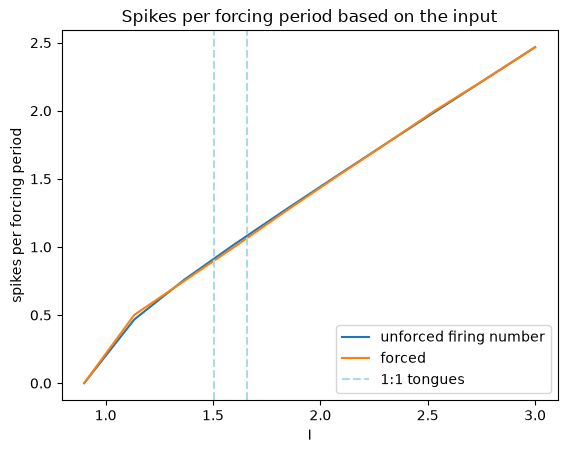

In [45]:
plt.plot(i_vals,un_forc,label = 'unforced firing number')
plt.plot(i_vals,np.array(firing_num),label ='forced')
plt.axvline(RH + Istar,linestyle = '--',color ='lightblue',label = '1:1 tongues')
plt.axvline(abs(RH - Istar),linestyle = '--',color ='lightblue')
plt.xlabel('I')
plt.ylabel('spikes per forcing period')
plt.title('Spikes per forcing period based on the input')
plt.legend()
plt.show()

My lines for forced and unforced firing number look very similar. I had to reduce my number of points to 10 (instead of 100) because my code took so long to run, but they are different functions and my code does work correctly. Ideally, the forced firing number would plateau at r=1 between the 1:1 tongues.

For the other plateaus, it will be when the firing rate is 1/2, 1/3, 2, and 2/3. These correspond to the 1:2 (1 spike every 2 periods of forcing), 1:3, 2:1, and 2:3 locking modes. On my graph, there should be horizontal plateaus at these values, but there is not enough points for them to be apparent. At $r=1/2$, a change in the slope is seen, and this is because of the 1:2 mode locking at this value. 

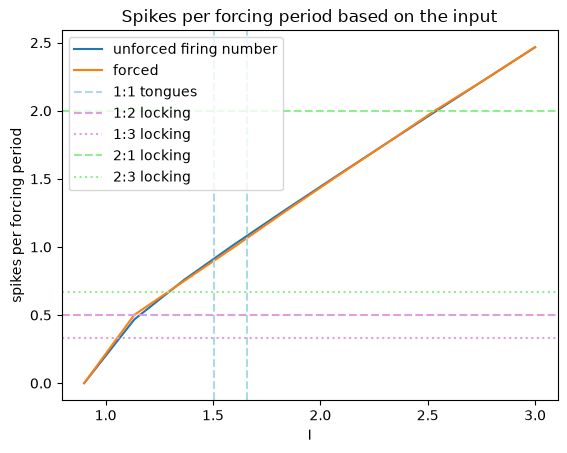

In [52]:
plt.plot(i_vals,un_forc,label = 'unforced firing number')
plt.plot(i_vals,np.array(firing_num),label ='forced')
plt.axvline(RH + Istar,linestyle = '--',color ='lightblue',label = '1:1 tongues')
plt.axvline(abs(RH - Istar),linestyle = '--',color ='lightblue')
plt.axhline(1/2,linestyle = '--', color = 'plum', label = '1:2 locking')
plt.axhline(1/3,linestyle = ':', color = 'plum', label = '1:3 locking')
plt.axhline(2,linestyle = '--', color = 'lightgreen', label = '2:1 locking')
plt.axhline(2/3,linestyle = ':', color = 'lightgreen', label = '2:3 locking')
plt.xlabel('I')
plt.ylabel('spikes per forcing period')
plt.title('Spikes per forcing period based on the input')
plt.legend()
plt.show()

For I=1.6, the phase of the spikes are 0.188 and 0.761 (as shown in 1b). For phase = 0.188, this means that the spikes occur 0.188 forcing periods after the beginning of each forcing cycle. For phase = 0.761, it is not a stable solution so it won't be the phase observed.